In [ ]:
import numpy as np
import matplotlib.pyplot as plt


#l = 1.100
#b = 0.036
t = 0.004

array100 = np.full(1600,100)

filename_startwerte = "3.6_messwert.xyz"
#filename_startwerte = f"{t}m_startwerte.xyz"
filename_gravitation = f"{t}m_gravitation.xyz"

data_startwerte = np.loadtxt(filename_startwerte)
data_gravitation = np.loadtxt(filename_gravitation)

#startwerte
x_SW = data_startwerte[:,0]*1/1000
y_SW = data_startwerte[:,1]*1/1000
z_SW = (data_startwerte[:,2]-array100)*1/1000


#gravitationswerte
x_GRAV = data_gravitation[:,0]
y_GRAV = data_gravitation[:,1]
z_GRAV = data_gravitation[:,2]


In [12]:
#endwerte
#array100 = np.array(1600)

x_EW = x_SW
y_EW = y_SW
z_EW = z_SW + z_GRAV

filename_endwerte = f"{t}m_endwerte.xyz"

with open(filename_endwerte, "w") as f:
    for i in range(len(x_EW)):
        x, y, w = x_EW[i],y_EW[i],z_EW[i]
        f.write(f"{x:.6f}\t{y:.6f}\t{w:.6e}\n")



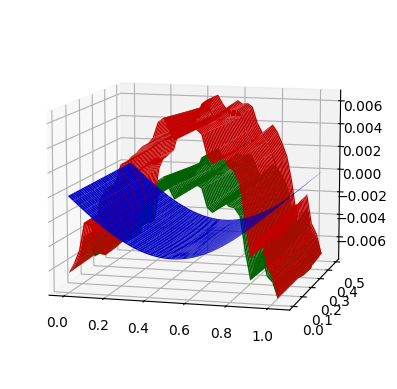

In [13]:
# Raster erzeugen
X = np.unique(x_SW)
Y = np.unique(y_SW)

X, Y = np.meshgrid(X, Y)
Z_SW=z_SW.reshape(len(Y), len(X))
Z_GRAV=z_GRAV.reshape(len(Y), len(X))
Z_EW=z_EW.reshape(len(Y), len(X))


fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot_surface(X, Y,Z_SW,color="red")          # startwerte
ax.plot_surface(X, Y,Z_GRAV,color="blue")       # gravitation
ax.plot_surface(X, Y,Z_EW,color="green")        # endwerte


ax.view_init(elev=10, azim=-75)
#plt.show()
